In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import math
from utils import draw_dot
from autograd.Value import Value
from autograd.Modules import MLP
%matplotlib inline

In [ ]:
def lol():
    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data
    
    a = Value(2.0 +h , label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label='e';
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data
    print(f"L1: {L1}")
    print(f"L2: {L2}")
    print(f"slop: {(L2 - L1)/ h}")
    
lol()

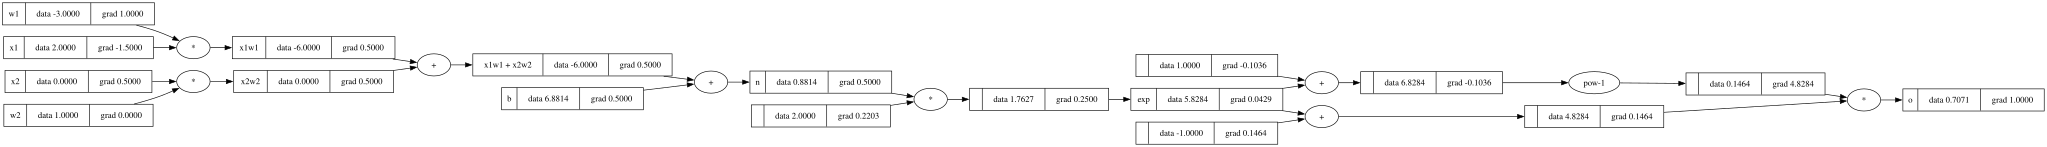

In [16]:
#Inputs 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weight
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735, label='b')
# x1*w1 + x2*w2 + b

x1w1 =  x1 * w1 ; x1w1.label='x1w1'
x2w2 =  x2 * w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label ='x1w1 + x2w2'
n = x1w1x2w2 + b; n.label='n'
# 
e = (2*n).exp()
o = (e - 1) / (e+ 1) 
o.label = 'o'
# o = n.tanh(); o.label = 'o'
o.backward()
draw_dot(o)


In [23]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0]
n = MLP(3, [4,4,1])

In [24]:
for k in range(100):
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
    #backward
    loss.backward()
    for p in n.parameters():
        p.data += -0.5 * p.grad
    for p in n.parameters():
        p.grad = 0.0
    print(k, loss.data)

0 4.101087577262711
1 5.461893436953101
2 3.9879769783362558
3 3.9793838089575804
4 3.9580007311374006
5 3.8306270672291496
6 0.05170018826871739
7 0.0011396816989728996
8 0.0010909584254752114
9 0.0010464878303188727
10 0.0010057186985195441
11 0.00096819297102522
12 0.0009335266108789332
13 0.0009013950419680334
14 0.0008715219257946771
15 0.0008436704104467794
16 0.0008176362347471973
17 0.0007932422413917177
18 0.0007703339720757648
19 0.0007487761019944088
20 0.0007284495316551222
21 0.0007092489979408951
22 0.0006910810987015207
23 0.0006738626491768704
24 0.0006575193065857006
25 0.0006419844128690512
26 0.0006271980160114099
27 0.0006131060384003301
28 0.000599659566925227
29 0.0005868142443947233
30 0.0005745297456939179
31 0.0005627693251464936
32 0.0005514994239739873
33 0.0005406893286906636
34 0.0005303108728418647
35 0.0005203381757660812
36 0.0005107474130971912
37 0.0005015166145717776
38 0.0004926254854039998
39 0.00048405524806648223
40 0.0004757885017933897
41 0.0004